## Mini  ml Project: Medical Insurance Cost Prediction

## By yogesh singh, batch 13

## 1. Import and Loading the Data.

•	Import required libraries (pandas, numpy, matplotlib, seaborn, sklearn, etc.)

•	Load the dataset and explore the structure using .head(), .info() and .describe()


In [3]:
import pandas as pd



# Load the dataset
df = pd.read_excel('Medical_Insurance_cost _prediction.xlsm')

# Explore the dataset
print("First 5 rows of the dataset:")
display(df.head())



First 5 rows of the dataset:


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [5]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [8]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [9]:
df.duplicated().sum()

np.int64(1)

In [10]:
print("Duplicated rows (including all occurrences):")
display(df[df.duplicated(keep=False)])

Duplicated rows (including all occurrences):


,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.5631
581,19,male,30.59,0,no,northwest,1639.5631


In [11]:
df.drop_duplicates(inplace=True)
print(f"Number of duplicate rows after dropping: {df.duplicated().sum()}")

Number of duplicate rows after dropping: 0


In [12]:
df.shape

(1337, 7)

In [13]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [16]:
df["smoker"].count()

np.int64(1337)

In [17]:
non_smokers = df[df['smoker'] == 'no'].shape[0]
print(f"Number of non-smokers: {non_smokers}")

Number of non-smokers: 1063


In [18]:
df['smoker'].value_counts()

,count
smoker,
no,1063
yes,274


In [19]:
df['children'].value_counts()

,count
children,
0,573
1,324
2,240
3,157
4,25
5,18


In [20]:
df['age'].value_counts()

,count
age,
18,69
19,67
46,29
52,29
50,29
47,29
48,29
51,29
45,29


## 2. Exploratory Data Analysis (EDA)

outlier detection

•	Visualize the distribution of each feature

•	Understand correlations (especially with the target variable)


--- Outlier Detection and Counts ---

Column: age
  Number of outliers: 0


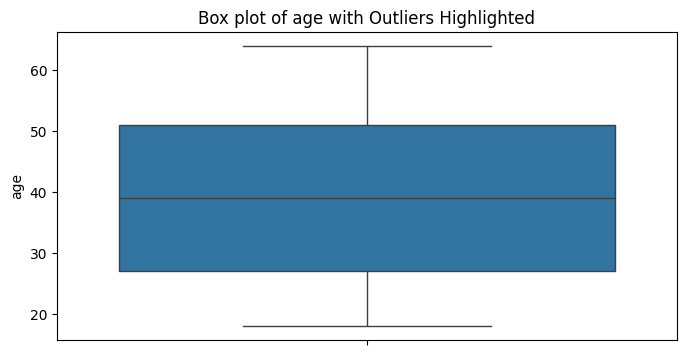


Column: bmi
  Number of outliers: 9
  Outlier values (first 5 if many):
[49.06, 48.07, 47.52, 47.41, 50.38]


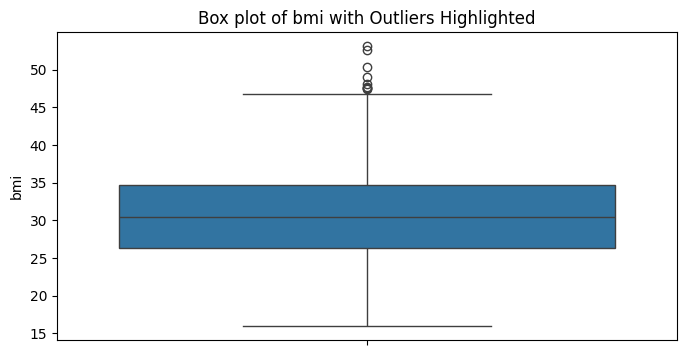


Column: children
  Number of outliers: 0


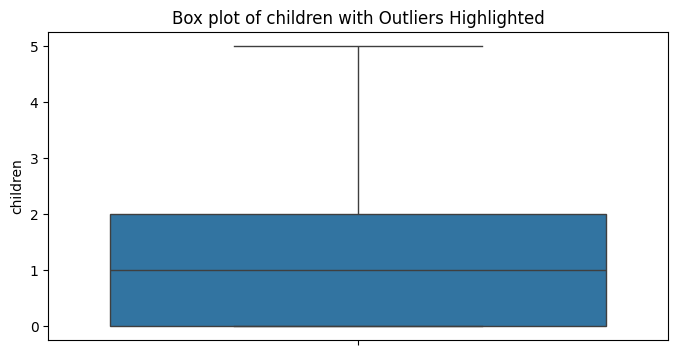


Column: charges
  Number of outliers: 139
  Outlier values (first 5 if many):
[39611.7577, 36837.467, 37701.8768, 38711.0, 35585.576]


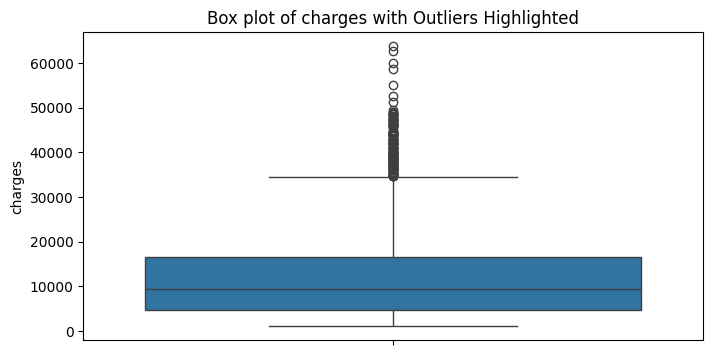


--- Infrequent Category Detection for Categorical Variables ---

Column: sex
sex
male      675
female    662
Name: count, dtype: int64
  No categories found below the infrequent threshold.

Column: smoker
smoker
no     1063
yes     274
Name: count, dtype: int64
  No categories found below the infrequent threshold.

Column: region
region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64
  No categories found below the infrequent threshold.


In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Outlier Detection and Counts ---")

# Numerical Outlier Detection (using IQR method)
numerical_cols = df.select_dtypes(include=['number']).columns

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    num_outliers = len(outliers)

    print(f"\nColumn: {col}")
    print(f"  Number of outliers: {num_outliers}")
    if num_outliers > 0:
        print(f"  Outlier values (first 5 if many):\n{outliers[col].head().tolist()}")

    # Optionally, visualize with a box plot
    plt.figure(figsize=(8, 4))
    sns.boxplot(y=df[col])
    plt.title(f'Box plot of {col} with Outliers Highlighted')
    plt.show()

# Categorical Infrequent Category Detection
categorical_cols = df.select_dtypes(include=['object']).columns

print("\n--- Infrequent Category Detection for Categorical Variables ---")
for col in categorical_cols:
    value_counts = df[col].value_counts()
    print(f"\nColumn: {col}")
    print(value_counts)
    # Define a threshold for 'infrequent' (e.g., less than 5% of total rows)
    threshold = len(df) * 0.05
    infrequent_categories = value_counts[value_counts < threshold]
    if not infrequent_categories.empty:
        print(f"  Infrequent categories (count < {int(threshold)}):\n{infrequent_categories.to_dict()}")
    else:
        print("  No categories found below the infrequent threshold.")


treating outlier of numerical veriable

In [24]:
import numpy as np

# List of numerical columns identified with outliers
numerical_cols_with_outliers = ['bmi', 'charges']

print("--- Treating Outliers using Capping (IQR Method) ---")

for col in numerical_cols_with_outliers:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Count outliers before capping
    outliers_before = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    num_outliers_before = len(outliers_before)

    # Apply capping
    df[col] = np.clip(df[col], lower_bound, upper_bound)

    # Count outliers after capping (should be 0)
    outliers_after = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    num_outliers_after = len(outliers_after)

    print(f"\nColumn: {col}")
    print(f"  Number of outliers before capping: {num_outliers_before}")
    print(f"  Number of outliers after capping: {num_outliers_after}")

print("\nOutlier treatment complete for specified numerical columns.")

# Display descriptive statistics after outlier treatment to see the effect
print("\nDescriptive statistics after outlier treatment:")
display(df[numerical_cols_with_outliers].describe())

--- Treating Outliers using Capping (IQR Method) ---

Column: bmi
  Number of outliers before capping: 9
  Number of outliers after capping: 0

Column: charges
  Number of outliers before capping: 139
  Number of outliers after capping: 0

Outlier treatment complete for specified numerical columns.

Descriptive statistics after outlier treatment:


,bmi,charges
count,1337.000000,1337.000000
mean,30.650247,12491.159952
std,6.059655,10165.511950
min,15.960000,1121.873900
25%,26.290000,4746.344000
50%,30.400000,9386.161300
75%,34.700000,16657.717450
max,47.315000,34524.777625


--- Visualizing 'bmi' and 'charges' after Outlier Treatment ---


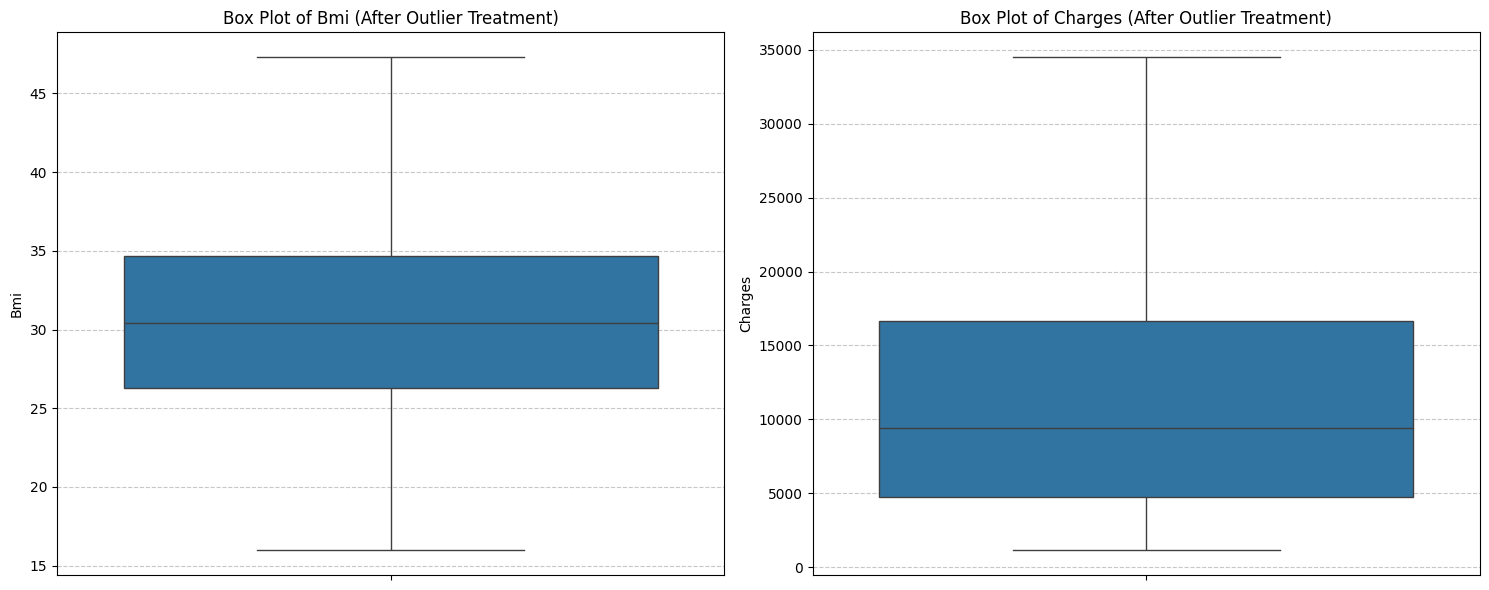

Visual inspection complete. The box plots should now show fewer or no extreme outliers beyond the whiskers.


In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols_after_treatment = ['bmi', 'charges']

print("--- Visualizing 'bmi' and 'charges' after Outlier Treatment ---")

plt.figure(figsize=(15, 6))

for i, col in enumerate(numerical_cols_after_treatment):
    plt.subplot(1, 2, i + 1) # Create 1 row, 2 columns, plot i+1
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col.capitalize()} (After Outlier Treatment)')
    plt.ylabel(col.capitalize())
    plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

print("Visual inspection complete. The box plots should now show fewer or no extreme outliers beyond the whiskers.")

## convert the catagorical variable into numerical veriable

In [28]:


# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns

print(f"Categorical columns to be encoded: {list(categorical_cols)}")



Categorical columns to be encoded: ['sex', 'smoker', 'region']


## using label encoding for sex and smoker and one hot encoding for region

In [30]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# Create a copy of the DataFrame to apply new encodings
df_encoded_specific = df.copy()

print("--- Applying Specific Encodings to Categorical Variables ---")

# Label Encoding for 'sex' and 'smoker'
le_sex = LabelEncoder()
df_encoded_specific['sex'] = le_sex.fit_transform(df_encoded_specific['sex'])
print(f"'sex' column encoded using Label Encoding. Mappings: {list(le_sex.classes_)} -> {list(le_sex.transform(le_sex.classes_))}")

le_smoker = LabelEncoder()
df_encoded_specific['smoker'] = le_smoker.fit_transform(df_encoded_specific['smoker'])
print(f"'smoker' column encoded using Label Encoding. Mappings: {list(le_smoker.classes_)} -> {list(le_smoker.transform(le_smoker.classes_))}")

# One-Hot Encoding for 'region'
df_encoded_specific = pd.get_dummies(df_encoded_specific, columns=['region'], drop_first=True)
print(" 'region' column encoded using One-Hot Encoding (drop_first=True).")

print("\nDataFrame after all specific encodings (first 5 rows):")
display(df_encoded_specific.head())

print("\nNew column information after encoding:")
df_encoded_specific.info()

--- Applying Specific Encodings to Categorical Variables ---
'sex' column encoded using Label Encoding. Mappings: ['female', 'male'] -> [np.int64(0), np.int64(1)]
'smoker' column encoded using Label Encoding. Mappings: ['no', 'yes'] -> [np.int64(0), np.int64(1)]
 'region' column encoded using One-Hot Encoding (drop_first=True).

DataFrame after all specific encodings (first 5 rows):


,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,False,False,True
1,18,1,33.770,1,0,1725.55230,False,True,False
2,28,1,33.000,3,0,4449.46200,False,True,False
3,33,1,22.705,0,0,21984.47061,True,False,False
4,32,1,28.880,0,0,3866.85520,True,False,False



New column information after encoding:
<class 'pandas.core.frame.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               1337 non-null   int64  
 1   sex               1337 non-null   int64  
 2   bmi               1337 non-null   float64
 3   children          1337 non-null   int64  
 4   smoker            1337 non-null   int64  
 5   charges           1337 non-null   float64
 6   region_northwest  1337 non-null   bool   
 7   region_southeast  1337 non-null   bool   
 8   region_southwest  1337 non-null   bool   
dtypes: bool(3), float64(2), int64(4)
memory usage: 77.0 KB


## check distribution of all variable

--- Visualizing Distribution of All Variables in df_encoded_specific ---

Distributions for Numerical Variables:


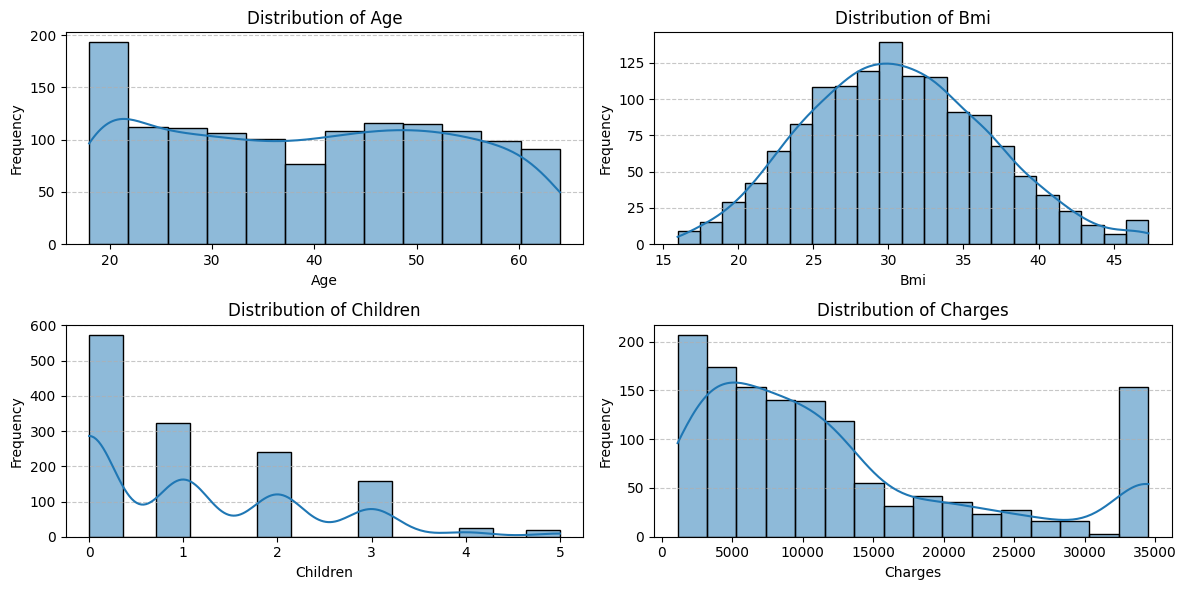


Distributions for Encoded Categorical Variables:


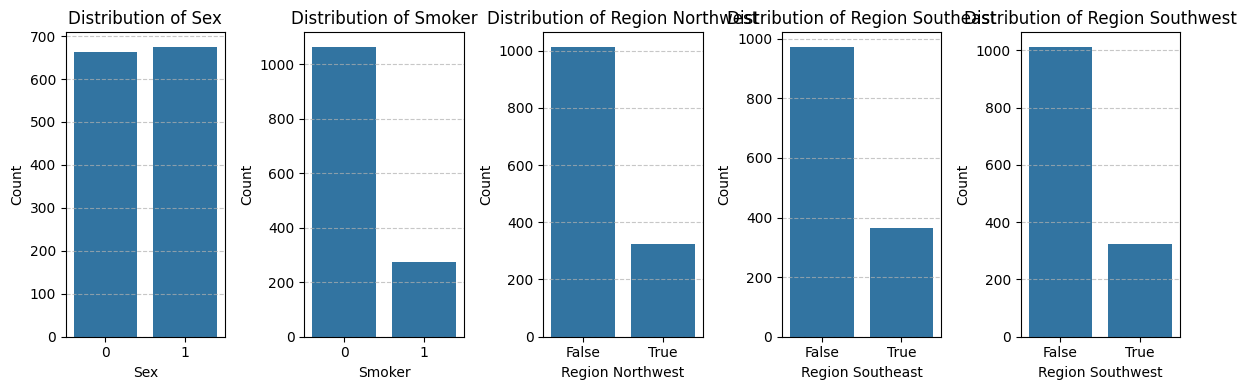

Distribution analysis complete.


In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Visualizing Distribution of All Variables in df_encoded_specific ---")

# Identify numerical and categorical (now encoded as int/bool) columns
numerical_cols = ['age', 'bmi', 'children', 'charges']
encoded_categorical_cols = ['sex', 'smoker', 'region_northwest', 'region_southeast', 'region_southwest']

# Plot distributions for numerical columns
print("\nDistributions for Numerical Variables:")
plt.figure(figsize=(12, 6))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 2, i + 1) # Arrange in 2 rows, 2 columns
    sns.histplot(df_encoded_specific[col], kde=True)
    plt.title(f'Distribution of {col.replace("_", " ").title()}')
    plt.xlabel(col.replace("_", " ").title())
    plt.ylabel('Frequency')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Plot distributions for encoded categorical columns
print("\nDistributions for Encoded Categorical Variables:")
plt.figure(figsize=(12, 4))
for i, col in enumerate(encoded_categorical_cols):
    plt.subplot(1, 5, i + 1) # Arrange in 1 row, 5 columns
    sns.countplot(x=df_encoded_specific[col])
    plt.title(f'Distribution of {col.replace("_", " ").title()}')
    plt.xlabel(col.replace("_", " ").title())
    plt.ylabel('Count')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Distribution analysis complete.")

## use log transformation for charges

--- Applying Log Transformation to 'charges' column ---
Original 'charges' column (first 5 rows):


,charges
0,16884.92400
1,1725.55230
2,4449.46200
3,21984.47061
4,3866.85520



Transformed 'charges_log' column (first 5 rows):


,charges_log
0,9.734236
1,7.453882
2,8.400763
3,9.998137
4,8.260455


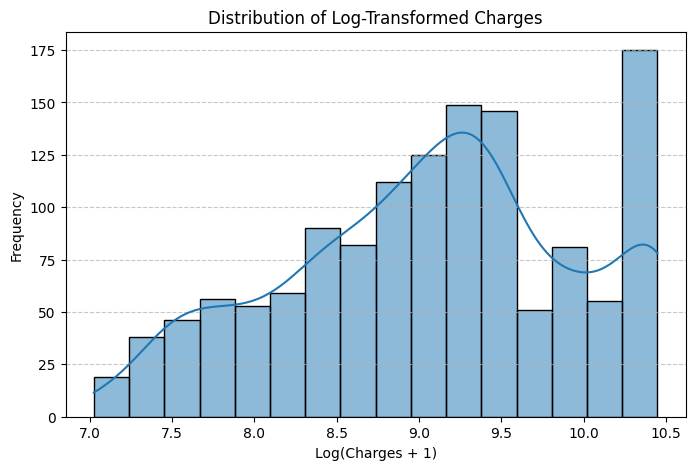

Log transformation applied and new distribution visualized. The 'charges_log' column has been added to the DataFrame.


In [34]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Applying Log Transformation to 'charges' column ---")

# Apply log1p transformation to the 'charges' column
df_encoded_specific['charges_log'] = np.log1p(df_encoded_specific['charges'])

print("Original 'charges' column (first 5 rows):")
display(df_encoded_specific[['charges']].head())

print("\nTransformed 'charges_log' column (first 5 rows):")
display(df_encoded_specific[['charges_log']].head())

# Visualize the distribution of the transformed 'charges' column
plt.figure(figsize=(8, 5))
sns.histplot(df_encoded_specific['charges_log'], kde=True)
plt.title('Distribution of Log-Transformed Charges')
plt.xlabel('Log(Charges + 1)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("Log transformation applied and new distribution visualized. The 'charges_log' column has been added to the DataFrame.")

## deal with class imbalance issue

In [35]:
from imblearn.over_sampling import SMOTE
from collections import Counter
import pandas as pd

print("--- Addressing Class Imbalance for 'smoker' variable using SMOTE ---")

# Separate features (X) and the 'smoker' variable (y)
# We'll treat 'smoker' as the target for this balancing operation.
# All other columns, including 'charges' and 'charges_log', will be used as features to generate synthetic samples.
X_smoker_balance = df_encoded_specific.drop('smoker', axis=1)
y_smoker_balance = df_encoded_specific['smoker']

print(f"Original 'smoker' distribution: {Counter(y_smoker_balance)}")

# Initialize SMOTE
sm = SMOTE(random_state=42)

# Apply SMOTE to the dataset
X_resampled, y_resampled = sm.fit_resample(X_smoker_balance, y_smoker_balance)

print(f"Resampled 'smoker' distribution: {Counter(y_resampled)}")

# Create a new DataFrame with the resampled data
df_smote_smoker = pd.concat([X_resampled, y_resampled], axis=1)

print("\nDataFrame after SMOTE (first 5 rows):")
display(df_smote_smoker.head())
print(f"New DataFrame shape: {df_smote_smoker.shape}")

--- Addressing Class Imbalance for 'smoker' variable using SMOTE ---
Original 'smoker' distribution: Counter({0: 1063, 1: 274})
Resampled 'smoker' distribution: Counter({1: 1063, 0: 1063})

DataFrame after SMOTE (first 5 rows):


,age,sex,bmi,children,charges,region_northwest,region_southeast,region_southwest,charges_log,smoker
0,19,0,27.900,0,16884.92400,False,False,True,9.734236,1
1,18,1,33.770,1,1725.55230,False,True,False,7.453882,0
2,28,1,33.000,3,4449.46200,False,True,False,8.400763,0
3,33,1,22.705,0,21984.47061,True,False,False,9.998137,0
4,32,1,28.880,0,3866.85520,True,False,False,8.260455,0


New DataFrame shape: (2126, 10)


The `smoker` variable has now been balanced using SMOTE. As you can see from the `Resampled 'smoker' distribution`, the number of 'yes' (smoker=1) instances has been significantly increased through the creation of synthetic samples to match the number of 'no' (smoker=0) instances.

**Important Considerations:**
*   **Synthetic Data:** SMOTE creates artificial data points. While it helps balance the classes, these synthetic points might not perfectly represent real-world data, especially for features like 'charges' if they were used to generate the synthetic samples.
*   **Regression vs. Classification:** SMOTE is primarily designed for classification problems to prevent models from being biased towards the majority class. For a regression task (predicting 'charges'), balancing a feature like 'smoker' (which is not the regression target) needs careful consideration. This step essentially changes the underlying distribution of your input features for the entire dataset.
*   **Feature Engineering:** If the goal is to improve the model's ability to handle the 'smoker' feature, other techniques like weighting or interaction terms might also be considered in a regression context.

## •	Feature scaling for numerical values (StandardScaler / MinMaxScaler)

In [37]:
from sklearn.preprocessing import RobustScaler
import pandas as pd

print("--- Applying RobustScaler to Numerical Features ---")

# Identify numerical columns for scaling
numerical_features_to_scale = ['age', 'bmi', 'children', 'charges_log']

# Create a RobustScaler instance
scaler = RobustScaler()

# Fit and transform the selected numerical features
df_smote_smoker[numerical_features_to_scale] = scaler.fit_transform(df_smote_smoker[numerical_features_to_scale])

print("Numerical features scaled successfully using RobustScaler. Displaying first 5 rows of the DataFrame with scaled values:")
display(df_smote_smoker.head())

print("\nDescriptive statistics for scaled numerical features:")
display(df_smote_smoker[numerical_features_to_scale].describe())

--- Applying RobustScaler to Numerical Features ---
Numerical features scaled successfully using RobustScaler. Displaying first 5 rows of the DataFrame with scaled values:


,age,sex,bmi,children,charges,region_northwest,region_southeast,region_southwest,charges_log,smoker
0,-0.791667,0,-0.304498,-0.5,16884.92400,False,False,True,0.000068,1
1,-0.833333,1,0.384289,0.0,1725.55230,False,True,False,-1.473629,0
2,-0.416667,1,0.293937,1.0,4449.46200,False,True,False,-0.861699,0
3,-0.208333,1,-0.914080,-0.5,21984.47061,True,False,False,0.170617,0
4,-0.250000,1,-0.189504,-0.5,3866.85520,True,False,False,-0.952374,0



Descriptive statistics for scaled numerical features:


,age,bmi,children,charges_log
count,2126.000000,2126.000000,2126.000000,2126.000000
mean,0.033572,0.023658,-0.017874,-0.153004
std,0.579830,0.702384,0.555537,0.585339
min,-0.833333,-1.705540,-0.500000,-1.751672
25%,-0.500000,-0.485368,-0.500000,-0.537711
50%,0.000000,0.000000,0.000000,0.000000
75%,0.500000,0.514632,0.500000,0.462289
max,1.083333,1.973662,2.000000,0.462289


keep the transformd charges

In [44]:
df_smote_smoker = df_smote_smoker.drop('charges', axis=1, errors='ignore')

In [45]:
df_smote_smoker

,age,sex,bmi,children,region_northwest,region_southeast,region_southwest,charges_log,smoker
0,-0.791667,0,-0.304498,-0.5,False,False,True,0.000068,1
1,-0.833333,1,0.384289,0.0,False,True,False,-1.473629,0
2,-0.416667,1,0.293937,1.0,False,True,False,-0.861699,0
3,-0.208333,1,-0.914080,-0.5,True,False,False,0.170617,0
4,-0.250000,1,-0.189504,-0.5,True,False,False,-0.952374,0
...,...,...,...,...,...,...,...,...,...
2121,-0.083333,1,-1.105922,0.0,True,True,False,0.013961,1
2122,0.875000,1,0.676744,-0.5,True,True,False,0.462289,1
2123,0.791667,1,1.321941,0.0,False,True,False,0.462289,1
2124,-0.125000,1,0.640507,0.0,False,True,False,0.462289,1


## divide data into x and y axis

In [46]:
X = df_smote_smoker.drop('charges_log', axis=1)
y = df_smote_smoker['charges_log']

print("Shape of X (features):")
print(X.shape)
print("Shape of y (target):")
print(y.shape)

print("\nFirst 5 rows of X:")
display(X.head())
print("\nFirst 5 values of y:")
display(y.head())

Shape of X (features):
(2126, 8)
Shape of y (target):
(2126,)

First 5 rows of X:


,age,sex,bmi,children,region_northwest,region_southeast,region_southwest,smoker
0,-0.791667,0,-0.304498,-0.5,False,False,True,1
1,-0.833333,1,0.384289,0.0,False,True,False,0
2,-0.416667,1,0.293937,1.0,False,True,False,0
3,-0.208333,1,-0.914080,-0.5,True,False,False,0
4,-0.250000,1,-0.189504,-0.5,True,False,False,0



First 5 values of y:


,charges_log
0,0.000068
1,-1.473629
2,-0.861699
3,0.170617
4,-0.952374


## divide it into training and testing

In [47]:
from sklearn.model_selection import train_test_split

print("--- Splitting data into training and testing sets ---")

# Split the data into training and testing sets (e.g., 80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

print("Data split successfully.")

--- Splitting data into training and testing sets ---
X_train shape: (1700, 8)
X_test shape: (426, 8)
y_train shape: (1700,)
y_test shape: (426,)
Data split successfully.


## model evaluation

linear regression

In [48]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("--- Training Linear Regression Model ---")

# Initialize the Linear Regression model
linear_reg_model = LinearRegression()

# Train the model using the training data
linear_reg_model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

--- Training Linear Regression Model ---
Linear Regression model trained successfully.


In [49]:
# Make predictions on the test set
y_pred = linear_reg_model.predict(X_test)

print("--- Evaluating Linear Regression Model ---")

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse) # Root Mean Squared Error
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R2): {r2:.4f}")

--- Evaluating Linear Regression Model ---
Mean Absolute Error (MAE): 0.1987
Mean Squared Error (MSE): 0.0730
Root Mean Squared Error (RMSE): 0.2702
R-squared (R2): 0.7999


desission tree regresser

In [59]:
from sklearn.tree import DecisionTreeRegressor

print("--- Training Decision Tree Regressor Model ---")

# Initialize the Decision Tree Regressor model
dt_reg_model = DecisionTreeRegressor(random_state=42)

# Train the model using the training data
dt_reg_model.fit(X_train, y_train)

print("Decision Tree Regressor model trained successfully.")

# Make predictions on the test set
y_pred_dt = dt_reg_model.predict(X_test)

print("\n--- Evaluating Decision Tree Regressor Model ---")

# Evaluate the model
mae_dt = mean_absolute_error(y_test, y_pred_dt)
mse_dt = mean_squared_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mse_dt)
r2_dt = r2_score(y_test, y_pred_dt)

# Calculate Adjusted R-squared
n = X_test.shape[0] # Number of observations
p = X_test.shape[1] # Number of features
adjusted_r2_dt = 1 - (1-r2_dt)*(n-1)/(n-p-1)

print(f"Mean Absolute Error (MAE) [Decision Tree]: {mae_dt:.4f}")
print(f"Mean Squared Error (MSE) [Decision Tree]: {mse_dt:.4f}")
print(f"Root Mean Squared Error (RMSE) [Decision Tree]: {rmse_dt:.4f}")
print(f"R-squared (R2) [Decision Tree]: {r2_dt:.4f}")
print(f"Adjusted R-squared [Decision Tree]: {adjusted_r2_dt:.4f}")

--- Training Decision Tree Regressor Model ---
Decision Tree Regressor model trained successfully.

--- Evaluating Decision Tree Regressor Model ---
Mean Absolute Error (MAE) [Decision Tree]: 0.0875
Mean Squared Error (MSE) [Decision Tree]: 0.0629
Root Mean Squared Error (RMSE) [Decision Tree]: 0.2507
R-squared (R2) [Decision Tree]: 0.8277
Adjusted R-squared [Decision Tree]: 0.8244


## random forest

In [58]:
from sklearn.ensemble import RandomForestRegressor

print("--- Training Random Forest Regressor Model ---")

# Initialize the Random Forest Regressor model
rf_reg_model = RandomForestRegressor(random_state=42)

# Train the model using the training data
rf_reg_model.fit(X_train, y_train)

print("Random Forest Regressor model trained successfully.")

# Make predictions on the test set
y_pred_rf = rf_reg_model.predict(X_test)

print("\n--- Evaluating Random Forest Regressor Model ---")

# Evaluate the model
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

# Calculate Adjusted R-squared
n = X_test.shape[0] # Number of observations
p = X_test.shape[1] # Number of features
adjusted_r2_rf = 1 - (1-r2_rf)*(n-1)/(n-p-1)

print(f"Mean Absolute Error (MAE) [Random Forest]: {mae_rf:.4f}")
print(f"Mean Squared Error (MSE) [Random Forest]: {mse_rf:.4f}")
print(f"Root Mean Squared Error (RMSE) [Random Forest]: {rmse_rf:.4f}")
print(f"R-squared (R2) [Random Forest]: {r2_rf:.4f}")
print(f"Adjusted R-squared [Random Forest]: {adjusted_r2_rf:.4f}")

--- Training Random Forest Regressor Model ---
Random Forest Regressor model trained successfully.

--- Evaluating Random Forest Regressor Model ---
Mean Absolute Error (MAE) [Random Forest]: 0.0846
Mean Squared Error (MSE) [Random Forest]: 0.0408
Root Mean Squared Error (RMSE) [Random Forest]: 0.2019
R-squared (R2) [Random Forest]: 0.8883
Adjusted R-squared [Random Forest]: 0.8862


## knn

In [57]:
from sklearn.neighbors import KNeighborsRegressor

print("--- Training K-Nearest Neighbors Regressor Model ---")

# Initialize the KNN Regressor model
knn_reg_model = KNeighborsRegressor(n_neighbors=5) # You can adjust n_neighbors

# Train the model using the training data
knn_reg_model.fit(X_train, y_train)

print("KNN Regressor model trained successfully.")

# Make predictions on the test set
y_pred_knn = knn_reg_model.predict(X_test)

print("\n--- Evaluating K-Nearest Neighbors Regressor Model ---")

# Evaluate the model
mae_knn = mean_absolute_error(y_test, y_pred_knn)
mse_knn = mean_squared_error(y_test, y_pred_knn)
rmse_knn = np.sqrt(mse_knn)
r2_knn = r2_score(y_test, y_pred_knn)

# Calculate Adjusted R-squared
n = X_test.shape[0] # Number of observations
p = X_test.shape[1] # Number of features
adjusted_r2_knn = 1 - (1-r2_knn)*(n-1)/(n-p-1)

print(f"Mean Absolute Error (MAE) [KNN]: {mae_knn:.4f}")
print(f"Mean Squared Error (MSE) [KNN]: {mse_knn:.4f}")
print(f"Root Mean Squared Error (RMSE) [KNN]: {rmse_knn:.4f}")
print(f"R-squared (R2) [KNN]: {r2_knn:.4f}")
print(f"Adjusted R-squared [KNN]: {adjusted_r2_knn:.4f}")

--- Training K-Nearest Neighbors Regressor Model ---
KNN Regressor model trained successfully.

--- Evaluating K-Nearest Neighbors Regressor Model ---
Mean Absolute Error (MAE) [KNN]: 0.1102
Mean Squared Error (MSE) [KNN]: 0.0445
Root Mean Squared Error (RMSE) [KNN]: 0.2109
R-squared (R2) [KNN]: 0.8781
Adjusted R-squared [KNN]: 0.8758


## svr

In [56]:
from sklearn.svm import SVR

print("--- Training Support Vector Regressor Model ---")

# Initialize the SVR model
# You can adjust parameters like kernel, C, epsilon based on performance
svr_model = SVR(kernel='rbf') # Radial Basis Function kernel is a common choice

# Train the model using the training data
svr_model.fit(X_train, y_train)

print("Support Vector Regressor model trained successfully.")

# Make predictions on the test set
y_pred_svr = svr_model.predict(X_test)

print("\n--- Evaluating Support Vector Regressor Model ---")

# Evaluate the model
mae_svr = mean_absolute_error(y_test, y_pred_svr)
mse_svr = mean_squared_error(y_test, y_pred_svr)
rmse_svr = np.sqrt(mse_svr)
r2_svr = r2_score(y_test, y_pred_svr)

# Calculate Adjusted R-squared
n = X_test.shape[0] # Number of observations
p = X_test.shape[1] # Number of features
adjusted_r2_svr = 1 - (1-r2_svr)*(n-1)/(n-p-1)

print(f"Mean Absolute Error (MAE) [SVR]: {mae_svr:.4f}")
print(f"Mean Squared Error (MSE) [SVR]: {mse_svr:.4f}")
print(f"Root Mean Squared Error (RMSE) [SVR]: {rmse_svr:.4f}")
print(f"R-squared (R2) [SVR]: {r2_svr:.4f}")
print(f"Adjusted R-squared [SVR]: {adjusted_r2_svr:.4f}")

--- Training Support Vector Regressor Model ---
Support Vector Regressor model trained successfully.

--- Evaluating Support Vector Regressor Model ---
Mean Absolute Error (MAE) [SVR]: 0.0966
Mean Squared Error (MSE) [SVR]: 0.0325
Root Mean Squared Error (RMSE) [SVR]: 0.1802
R-squared (R2) [SVR]: 0.9110
Adjusted R-squared [SVR]: 0.9093


## xg bbost

## XGBoost Regressor

In [55]:
import xgboost as xgb

print("--- Training XGBoost Regressor Model ---")

# Initialize the XGBoost Regressor model
xgb_reg_model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1, random_state=42)

# Train the model using the training data
xgb_reg_model.fit(X_train, y_train)

print("XGBoost Regressor model trained successfully.")

# Make predictions on the test set
y_pred_xgb = xgb_reg_model.predict(X_test)

print("\n--- Evaluating XGBoost Regressor Model ---")

# Evaluate the model
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

# Calculate Adjusted R-squared
n = X_test.shape[0] # Number of observations
p = X_test.shape[1] # Number of features
adjusted_r2_xgb = 1 - (1-r2_xgb)*(n-1)/(n-p-1)

print(f"Mean Absolute Error (MAE) [XGBoost]: {mae_xgb:.4f}")
print(f"Mean Squared Error (MSE) [XGBoost]: {mse_xgb:.4f}")
print(f"Root Mean Squared Error (RMSE) [XGBoost]: {rmse_xgb:.4f}")
print(f"R-squared (R2) [XGBoost]: {r2_xgb:.4f}")
print(f"Adjusted R-squared [XGBoost]: {adjusted_r2_xgb:.4f}")

--- Training XGBoost Regressor Model ---
XGBoost Regressor model trained successfully.

--- Evaluating XGBoost Regressor Model ---
Mean Absolute Error (MAE) [XGBoost]: 0.0907
Mean Squared Error (MSE) [XGBoost]: 0.0414
Root Mean Squared Error (RMSE) [XGBoost]: 0.2036
R-squared (R2) [XGBoost]: 0.8865
Adjusted R-squared [XGBoost]: 0.8843


## by xgboost

In [64]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("--- Hyperparameter Tuning for XGBoost Regressor using GridSearchCV ---")

# Define the parameter grid for XGBoost Regressor
param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7]
}

# Initialize GridSearchCV
grid_search_xgb = GridSearchCV(estimator=xgb.XGBRegressor(objective='reg:squarederror', random_state=42),
                               param_grid=param_grid_xgb,
                               scoring='r2',
                               cv=3,
                               n_jobs=-1,
                               verbose=1)

# Fit GridSearchCV on the training data
grid_search_xgb.fit(X_train, y_train)

print("GridSearchCV for XGBoost completed.")

# Get the best parameters and best score
best_params_xgb = grid_search_xgb.best_params_
best_score_xgb = grid_search_xgb.best_score_

print(f"\nBest parameters for XGBoost: {best_params_xgb}")
print(f"Best R-squared score on training data (cross-validated): {best_score_xgb:.4f}")

# Get the best XGBoost model
best_xgb_model = grid_search_xgb.best_estimator_

# Make predictions on the test set with the best XGBoost model
y_pred_best_xgb = best_xgb_model.predict(X_test)

print("\n--- Evaluating Best XGBoost Model on Test Set ---")

# Evaluate the best XGBoost model
mae_best_xgb = mean_absolute_error(y_test, y_pred_best_xgb)
mse_best_xgb = mean_squared_error(y_test, y_pred_best_xgb)
rmse_best_xgb = np.sqrt(mse_best_xgb)
r2_best_xgb = r2_score(y_test, y_pred_best_xgb)

# Calculate Adjusted R-squared for the best XGBoost model
n = X_test.shape[0] # Number of observations
p = X_test.shape[1] # Number of features
adjusted_r2_best_xgb = 1 - (1-r2_best_xgb)*(n-1)/(n-p-1)

print(f"Mean Absolute Error (MAE) [Best XGBoost]: {mae_best_xgb:.4f}")
print(f"Mean Squared Error (MSE) [Best XGBoost]: {mse_best_xgb:.4f}")
print(f"Root Mean Squared Error (RMSE) [Best XGBoost]: {rmse_best_xgb:.4f}")
print(f"R-squared (R2) [Best XGBoost]: {r2_best_xgb:.4f}")
print(f"Adjusted R-squared [Best XGBoost]: {adjusted_r2_best_xgb:.4f}")

--- Hyperparameter Tuning for XGBoost Regressor using GridSearchCV ---
Fitting 3 folds for each of 27 candidates, totalling 81 fits
GridSearchCV for XGBoost completed.

Best parameters for XGBoost: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Best R-squared score on training data (cross-validated): 0.8832

--- Evaluating Best XGBoost Model on Test Set ---
Mean Absolute Error (MAE) [Best XGBoost]: 0.0867
Mean Squared Error (MSE) [Best XGBoost]: 0.0332
Root Mean Squared Error (RMSE) [Best XGBoost]: 0.1823
R-squared (R2) [Best XGBoost]: 0.9089
Adjusted R-squared [Best XGBoost]: 0.9072


## Compare performance on both datasets (Training and testing) to detect overfitting

In [60]:
import pandas as pd

# Dictionary to store results
results = []

# --- Linear Regression ---
y_pred_train_lr = linear_reg_model.predict(X_train)
r2_train_lr = r2_score(y_train, y_pred_train_lr)
n_train = X_train.shape[0]
p_train = X_train.shape[1]
adjusted_r2_train_lr = 1 - (1-r2_train_lr)*(n_train-1)/(n_train-p_train-1)
results.append({'Model': 'Linear Regression', 'Dataset': 'Train', 'R2': r2_train_lr, 'Adjusted R2': adjusted_r2_train_lr})
results.append({'Model': 'Linear Regression', 'Dataset': 'Test', 'R2': r2, 'Adjusted R2': None}) # Use existing test R2

# --- Decision Tree Regressor ---
y_pred_train_dt = dt_reg_model.predict(X_train)
r2_train_dt = r2_score(y_train, y_pred_train_dt)
adjusted_r2_train_dt = 1 - (1-r2_train_dt)*(n_train-1)/(n_train-p_train-1)
results.append({'Model': 'Decision Tree Regressor', 'Dataset': 'Train', 'R2': r2_train_dt, 'Adjusted R2': adjusted_r2_train_dt})
results.append({'Model': 'Decision Tree Regressor', 'Dataset': 'Test', 'R2': r2_dt, 'Adjusted R2': adjusted_r2_dt})

# --- Random Forest Regressor ---
y_pred_train_rf = rf_reg_model.predict(X_train)
r2_train_rf = r2_score(y_train, y_pred_train_rf)
adjusted_r2_train_rf = 1 - (1-r2_train_rf)*(n_train-1)/(n_train-p_train-1)
results.append({'Model': 'Random Forest Regressor', 'Dataset': 'Train', 'R2': r2_train_rf, 'Adjusted R2': adjusted_r2_train_rf})
results.append({'Model': 'Random Forest Regressor', 'Dataset': 'Test', 'R2': r2_rf, 'Adjusted R2': adjusted_r2_rf})

# --- K-Nearest Neighbors (KNN) Regressor ---
y_pred_train_knn = knn_reg_model.predict(X_train)
r2_train_knn = r2_score(y_train, y_pred_train_knn)
adjusted_r2_train_knn = 1 - (1-r2_train_knn)*(n_train-1)/(n_train-p_train-1)
results.append({'Model': 'K-Nearest Neighbors (KNN) Regressor', 'Dataset': 'Train', 'R2': r2_train_knn, 'Adjusted R2': adjusted_r2_train_knn})
results.append({'Model': 'K-Nearest Neighbors (KNN) Regressor', 'Dataset': 'Test', 'R2': r2_knn, 'Adjusted R2': adjusted_r2_knn})

# --- Support Vector Regressor (SVR) ---
y_pred_train_svr = svr_model.predict(X_train)
r2_train_svr = r2_score(y_train, y_pred_train_svr)
adjusted_r2_train_svr = 1 - (1-r2_train_svr)*(n_train-1)/(n_train-p_train-1)
results.append({'Model': 'Support Vector Regressor (SVR)', 'Dataset': 'Train', 'R2': r2_train_svr, 'Adjusted R2': adjusted_r2_train_svr})
results.append({'Model': 'Support Vector Regressor (SVR)', 'Dataset': 'Test', 'R2': r2_svr, 'Adjusted R2': adjusted_r2_svr})

# --- XGBoost Regressor ---
y_pred_train_xgb = xgb_reg_model.predict(X_train)
r2_train_xgb = r2_score(y_train, y_pred_train_xgb)
adjusted_r2_train_xgb = 1 - (1-r2_train_xgb)*(n_train-1)/(n_train-p_train-1)
results.append({'Model': 'XGBoost Regressor', 'Dataset': 'Train', 'R2': r2_train_xgb, 'Adjusted R2': adjusted_r2_train_xgb})
results.append({'Model': 'XGBoost Regressor', 'Dataset': 'Test', 'R2': r2_xgb, 'Adjusted R2': adjusted_r2_xgb})

# Create a DataFrame from results
comparison_df = pd.DataFrame(results)

print("\n--- Model Performance Comparison (Training vs. Testing) ---")
display(comparison_df.round(4))

print("\n*Note: A significant difference between training and testing R2/Adjusted R2 indicates potential overfitting. A higher training score than testing score is expected, but a large gap suggests overfitting. Conversely, if both scores are low, the model might be underfitting or performing poorly overall.*")


--- Model Performance Comparison (Training vs. Testing) ---


,Model,Dataset,R2,Adjusted R2
0,Linear Regression,Train,0.7795,0.7784
1,Linear Regression,Test,0.7999,NaN
2,Decision Tree Regressor,Train,1.0000,1.0000
3,Decision Tree Regressor,Test,0.8277,0.8244
4,Random Forest Regressor,Train,0.9822,0.9821
5,Random Forest Regressor,Test,0.8883,0.8862
6,K-Nearest Neighbors (KNN) Regressor,Train,0.9052,0.9047
7,K-Nearest Neighbors (KNN) Regressor,Test,0.8781,0.8758
8,Support Vector Regressor (SVR),Train,0.8905,0.8900
9,Support Vector Regressor (SVR),Test,0.9110,0.9093



*Note: A significant difference between training and testing R2/Adjusted R2 indicates potential overfitting. A higher training score than testing score is expected, but a large gap suggests overfitting. Conversely, if both scores are low, the model might be underfitting or performing poorly overall.*


## 7. Hyperparameter Tuning

•	Use GridSearchCV or RandomizedSearchCV to optimize the best-performing models

•	Document best parameters and improvement in performance


In [62]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("--- Hyperparameter Tuning for Support Vector Regressor (SVR) using GridSearchCV ---")

# Define the parameter grid for SVR
param_grid_svr = {
    'kernel': ['rbf'],
    'C': [0.1, 1, 10, 100],
    'epsilon': [0.01, 0.1, 0.2, 0.5]
}

# Initialize GridSearchCV
grid_search_svr = GridSearchCV(estimator=SVR(),
                               param_grid=param_grid_svr,
                               scoring='r2',
                               cv=5,
                               n_jobs=-1,
                               verbose=1)

# Fit GridSearchCV on the training data
grid_search_svr.fit(X_train, y_train)

print("GridSearchCV for SVR completed.")

# Get the best parameters and best score
best_params_svr = grid_search_svr.best_params_
best_score_svr = grid_search_svr.best_score_

print(f"\nBest parameters for SVR: {best_params_svr}")
print(f"Best R-squared score on training data (cross-validated): {best_score_svr:.4f}")

# Get the best SVR model
best_svr_model = grid_search_svr.best_estimator_

# Make predictions on the test set with the best SVR model
y_pred_best_svr = best_svr_model.predict(X_test)

print("\n--- Evaluating Best SVR Model on Test Set ---")

# Evaluate the best SVR model
mae_best_svr = mean_absolute_error(y_test, y_pred_best_svr)
mse_best_svr = mean_squared_error(y_test, y_pred_best_svr)
rmse_best_svr = np.sqrt(mse_best_svr)
r2_best_svr = r2_score(y_test, y_pred_best_svr)

# Calculate Adjusted R-squared for the best SVR model
n = X_test.shape[0] # Number of observations
p = X_test.shape[1] # Number of features
adjusted_r2_best_svr = 1 - (1-r2_best_svr)*(n-1)/(n-p-1)

print(f"Mean Absolute Error (MAE) [Best SVR]: {mae_best_svr:.4f}")
print(f"Mean Squared Error (MSE) [Best SVR]: {mse_best_svr:.4f}")
print(f"Root Mean Squared Error (RMSE) [Best SVR]: {rmse_best_svr:.4f}")
print(f"R-squared (R2) [Best SVR]: {r2_best_svr:.4f}")
print(f"Adjusted R-squared [Best SVR]: {adjusted_r2_best_svr:.4f}")

--- Hyperparameter Tuning for Support Vector Regressor (SVR) using GridSearchCV ---
Fitting 5 folds for each of 16 candidates, totalling 80 fits
GridSearchCV for SVR completed.

Best parameters for SVR: {'C': 10, 'epsilon': 0.01, 'kernel': 'rbf'}
Best R-squared score on training data (cross-validated): 0.8818

--- Evaluating Best SVR Model on Test Set ---
Mean Absolute Error (MAE) [Best SVR]: 0.0591
Mean Squared Error (MSE) [Best SVR]: 0.0333
Root Mean Squared Error (RMSE) [Best SVR]: 0.1824
R-squared (R2) [Best SVR]: 0.9089
Adjusted R-squared [Best SVR]: 0.9071


## 8. Model Comparison Table
Create a comparison table like below:
Model	Train RMSE	Test RMSE	Train R²	Test R²	Overfitting (Y/N)


In [66]:
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Function to calculate RMSE
def calculate_rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# Initialize lists to store metrics for the comparison table
comparison_data = []

# --- Linear Regression ---
# Make predictions on the training set for Linear Regression
y_pred_train_lr = linear_reg_model.predict(X_train)
rmse_train_lr = calculate_rmse(y_train, y_pred_train_lr)
r2_train_lr = r2_score(y_train, y_pred_train_lr)
comparison_data.append({
    'Model': 'Linear Regression',
    'Train RMSE': rmse_train_lr,
    'Test RMSE': rmse,
    'Train R^2': r2_train_lr,
    'Test R^2': r2
})

# --- Decision Tree Regressor ---
# y_pred_train_dt was already calculated and r2_train_dt as well
rmse_train_dt = calculate_rmse(y_train, y_pred_train_dt)
comparison_data.append({
    'Model': 'Decision Tree Regressor',
    'Train RMSE': rmse_train_dt,
    'Test RMSE': rmse_dt,
    'Train R^2': r2_train_dt,
    'Test R^2': r2_dt
})

# --- Random Forest Regressor ---
# y_pred_train_rf was already calculated and r2_train_rf as well
rmse_train_rf = calculate_rmse(y_train, y_pred_train_rf)
comparison_data.append({
    'Model': 'Random Forest Regressor',
    'Train RMSE': rmse_train_rf,
    'Test RMSE': rmse_rf,
    'Train R^2': r2_train_rf,
    'Test R^2': r2_rf
})

# --- K-Nearest Neighbors (KNN) Regressor ---
# y_pred_train_knn was already calculated and r2_train_knn as well
rmse_train_knn = calculate_rmse(y_train, y_pred_train_knn)
comparison_data.append({
    'Model': 'K-Nearest Neighbors (KNN) Regressor',
    'Train RMSE': rmse_train_knn,
    'Test RMSE': rmse_knn,
    'Train R^2': r2_train_knn,
    'Test R^2': r2_knn
})

# --- Support Vector Regressor (SVR) (Before Tuning) ---
# y_pred_train_svr was already calculated and r2_train_svr as well
rmse_train_svr = calculate_rmse(y_train, y_pred_train_svr)
comparison_data.append({
    'Model': 'Support Vector Regressor (SVR) (Before Tuning)',
    'Train RMSE': rmse_train_svr,
    'Test RMSE': rmse_svr,
    'Train R^2': r2_train_svr,
    'Test R^2': r2_svr
})

# --- Support Vector Regressor (SVR) (After Tuning) ---
# Use the best_svr_model for predictions
y_pred_train_best_svr = best_svr_model.predict(X_train)
rmse_train_best_svr = calculate_rmse(y_train, y_pred_train_best_svr)
r2_train_best_svr = r2_score(y_train, y_pred_train_best_svr)
comparison_data.append({
    'Model': 'Support Vector Regressor (SVR) (After Tuning)',
    'Train RMSE': rmse_train_best_svr,
    'Test RMSE': rmse_best_svr,
    'Train R^2': r2_train_best_svr,
    'Test R^2': r2_best_svr
})

# --- XGBoost Regressor (Before Tuning) ---
# y_pred_train_xgb was already calculated and r2_train_xgb as well
rmse_train_xgb = calculate_rmse(y_train, y_pred_train_xgb)
comparison_data.append({
    'Model': 'XGBoost Regressor (Before Tuning)',
    'Train RMSE': rmse_train_xgb,
    'Test RMSE': rmse_xgb,
    'Train R^2': r2_train_xgb,
    'Test R^2': r2_xgb
})

# --- XGBoost Regressor (After Tuning) ---
# Calculate training metrics for the best XGBoost model
y_pred_train_best_xgb = best_xgb_model.predict(X_train)
rmse_train_best_xgb = calculate_rmse(y_train, y_pred_train_best_xgb)
r2_train_best_xgb = r2_score(y_train, y_pred_train_best_xgb)
comparison_data.append({
    'Model': 'XGBoost Regressor (After Tuning)',
    'Train RMSE': rmse_train_best_xgb,
    'Test RMSE': rmse_best_xgb,
    'Train R^2': r2_train_best_xgb,
    'Test R^2': r2_best_xgb
})

# Create DataFrame
comparison_table_df = pd.DataFrame(comparison_data)

# Add 'Overfitting (Y/N)' column based on a simple heuristic (e.g., if Train R^2 is significantly higher than Test R^2)
def check_overfitting(row):
    # A difference of more than 0.05 or 5% is often considered a sign of overfitting.
    # This is a heuristic and can be adjusted.
    r2_diff = row['Train R^2'] - row['Test R^2']
    if r2_diff > 0.05: # You can adjust this threshold
        return 'Yes'
    else:
        return 'No'

comparison_table_df['Overfitting (Y/N)'] = comparison_table_df.apply(check_overfitting, axis=1)

print("\n--- Model Performance Comparison Table ---")
display(comparison_table_df.round(4))

print("\n*Overfitting is determined if the difference between Train R^2 and Test R^2 is greater than 0.05. This threshold can be adjusted based on domain knowledge and specific project requirements.*")


--- Model Performance Comparison Table ---


,Model,Train RMSE,Test RMSE,Train R^2,Test R^2,Overfitting (Y/N)
0,Linear Regression,0.2725,0.2702,0.7795,0.7999,No
1,Decision Tree Regressor,0.0000,0.2507,1.0000,0.8277,Yes
2,Random Forest Regressor,0.0775,0.2019,0.9822,0.8883,Yes
3,K-Nearest Neighbors (KNN) Regressor,0.1787,0.2109,0.9052,0.8781,No
4,Support Vector Regressor (SVR) (Before Tuning),0.1920,0.1802,0.8905,0.9110,No
5,Support Vector Regressor (SVR) (After Tuning),0.1914,0.1824,0.8913,0.9089,No
6,XGBoost Regressor (Before Tuning),0.0967,0.2036,0.9722,0.8865,Yes
7,XGBoost Regressor (After Tuning),0.1737,0.1823,0.9104,0.9089,No



*Overfitting is determined if the difference between Train R^2 and Test R^2 is greater than 0.05. This threshold can be adjusted based on domain knowledge and specific project requirements.*


## save the best model

In [67]:
import joblib

# Save the best XGBoost model
joblib.dump(best_xgb_model, 'best_xgboost_model.joblib')
print("Best XGBoost model saved as 'best_xgboost_model.joblib'")

Best XGBoost model saved as 'best_xgboost_model.joblib'


## pkl file

In [68]:
import joblib

# Save the best XGBoost model as a .pkl file
joblib.dump(best_xgb_model, 'best_xgboost_model.pkl')
print("Best XGBoost model saved as 'best_xgboost_model.pkl' for Streamlit deployment.")

Best XGBoost model saved as 'best_xgboost_model.pkl' for Streamlit deployment.
